In [ ]:
pip install notebook pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
df = pd.read_csv("/cricket.csv.txt")
df.head()

,Match_No,Innings,Team,Player,Ballcount,Position,Description,Pick,Throw,Runs,Over
0,1,1,India,Virat Kohli,1,Cover,Stopped boundary,Clean Pick,Good Throw,2,1
1,1,1,India,Rohit Sharma,2,Midwicket,Misfield,Fumble,Bad Throw,-3,1
2,1,1,India,Hardik Pandya,3,Point,Runout attempt,Clean Pick,Run Out,3,1
3,1,1,India,Virat Kohli,4,Cover,Catch taken,Clean Pick,Catch,4,2
4,1,1,India,Rohit Sharma,5,Midwicket,Dropped catch,Fumble,Drop Catch,-4,2


In [ ]:
def calculate_score(row):
    score = 0

    if row["Pick"] in weights:
        score += weights[row["Pick"]]

    if row["Throw"] in weights:
        score += weights[row["Throw"]]

    score += row["Runs"]
    return score
df["Performance_Score"] = df.apply(calculate_score, axis=1)
df

,Match_No,Innings,Team,Player,Ballcount,Position,Description,Pick,Throw,Runs,Over,Performance_Score
0,1,1,India,Virat Kohli,1,Cover,Stopped boundary,Clean Pick,Good Throw,2,1,6
1,1,1,India,Rohit Sharma,2,Midwicket,Misfield,Fumble,Bad Throw,-3,1,-8
2,1,1,India,Hardik Pandya,3,Point,Runout attempt,Clean Pick,Run Out,3,1,11
3,1,1,India,Virat Kohli,4,Cover,Catch taken,Clean Pick,Catch,4,2,11
4,1,1,India,Rohit Sharma,5,Midwicket,Dropped catch,Fumble,Drop Catch,-4,2,-11


In [ ]:
player_performance = df.groupby("Player")["Performance_Score"].sum()
player_performance

,Performance_Score
Player,
Hardik Pandya,11
Rohit Sharma,-19
Virat Kohli,17


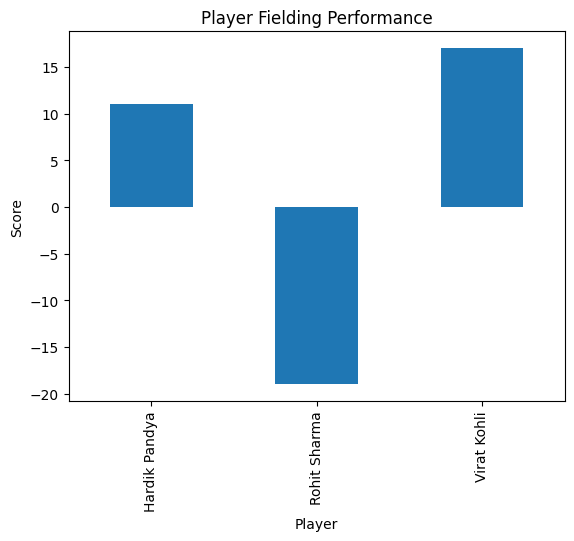

In [ ]:
import matplotlib.pyplot as plt

player_performance.plot(kind='bar')
plt.title("Player Fielding Performance")
plt.xlabel("Player")
plt.ylabel("Score")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/financial.csv.txt")
df["Date"] = pd.to_datetime(df["Date"])
df

,Date,Fiscal_Year,Gross_Sales,Net_Sales,COGS,Manufacturing_Cost,Freight_Cost
0,2023-01-01,2023,1000,900,400,200,50
1,2023-02-01,2023,1200,1000,500,250,60
2,2023-03-01,2023,1500,1300,600,300,80
3,2024-01-01,2024,1800,1500,700,350,100
4,2024-02-01,2024,2000,1700,800,400,120
5,2024-03-01,2024,2200,1900,900,450,150


In [ ]:
df["Profit"] = df["Net_Sales"] - (df["COGS"] + df["Manufacturing_Cost"] + df["Freight_Cost"])
df

,Date,Fiscal_Year,Gross_Sales,Net_Sales,COGS,Manufacturing_Cost,Freight_Cost,Profit
0,2023-01-01,2023,1000,900,400,200,50,250
1,2023-02-01,2023,1200,1000,500,250,60,190
2,2023-03-01,2023,1500,1300,600,300,80,320
3,2024-01-01,2024,1800,1500,700,350,100,350
4,2024-02-01,2024,2000,1700,800,400,120,380
5,2024-03-01,2024,2200,1900,900,450,150,400


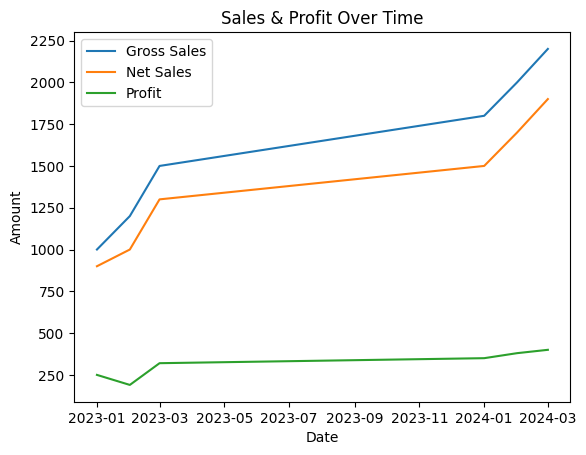

In [ ]:
plt.figure()
plt.plot(df["Date"], df["Gross_Sales"])
plt.plot(df["Date"], df["Net_Sales"])
plt.plot(df["Date"], df["Profit"])
plt.title("Sales & Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend(["Gross Sales", "Net Sales", "Profit"])
plt.show()

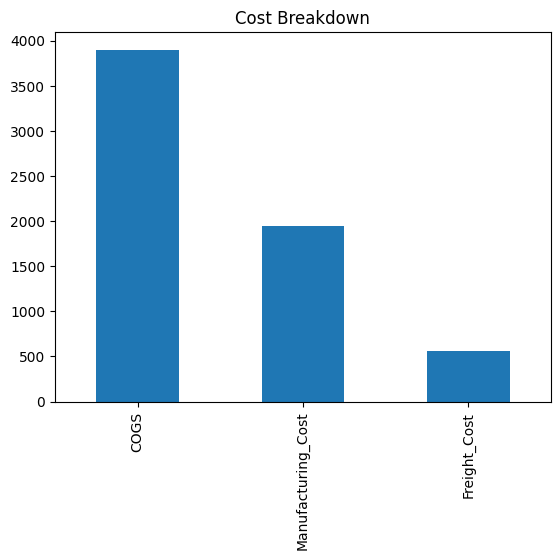

In [ ]:
costs = df[["COGS", "Manufacturing_Cost", "Freight_Cost"]].sum()

plt.figure()
costs.plot(kind="bar")
plt.title("Cost Breakdown")
plt.show()

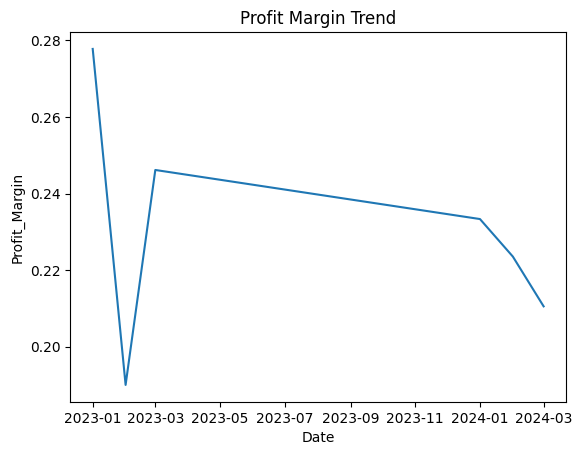

In [ ]:
df["Profit_Margin"] = df["Profit"] / df["Net_Sales"]

plt.figure()
sns.lineplot(x="Date", y="Profit_Margin", data=df)
plt.title("Profit Margin Trend")
plt.show()

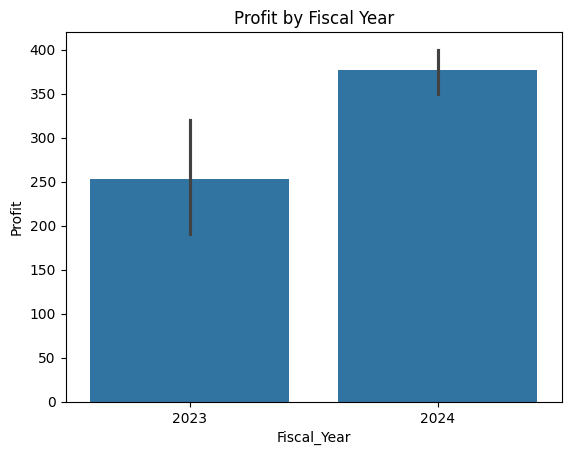

In [ ]:
sns.barplot(x="Fiscal_Year", y="Profit", data=df)
plt.title("Profit by Fiscal Year")
plt.show()

In [ ]:
from transformers import pipeline
nlp = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
texts = [
    "The product performance is excellent",
    "The results are very disappointing",
    "Sales increased significantly this year"
]

results = [nlp(text)[0] for text in texts]
results

[{'label': 'POSITIVE', 'score': 0.9998654127120972},
 {'label': 'NEGATIVE', 'score': 0.9997599720954895},
 {'label': 'POSITIVE', 'score': 0.999674916267395}]

In [ ]:
import pandas as pd

df_nlp = pd.DataFrame(results)
df_nlp["Text"] = texts
df_nlp

,label,score,Text
0,POSITIVE,0.999865,The product performance is excellent
1,NEGATIVE,0.999760,The results are very disappointing
2,POSITIVE,0.999675,Sales increased significantly this year


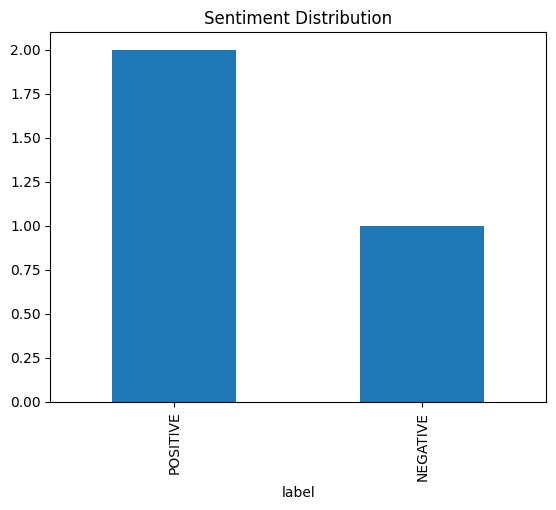

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df_nlp["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()